# 05_统计检验方法-非参数检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家来聊聊统计检验方法：非参数检验\~

统计检验方法就是通过一些数学方法，帮助我们判断一个假设或结论是否成立。比如，你想知道某个药物是不是有效，统计检验就可以帮你判断药物的效果是否达到了统计上的显著性。

#### 非参数检验是什么？

在统计学里，通常我们会做一些假设，比如假设某个数据分布是正态分布（也就是钟形曲线的那种）。然后通过一些方法（比如t检验、卡方检验等）来检验数据是否符合这些假设。

但是，有时候数据不符合这些假设（比如数据可能没有正态分布），或者你根本不想假设数据的分布。这个时候，非参数检验就派上用场了。

简单来说，**非参数检验**是一种不依赖于数据分布的检验方法，它不要求数据必须符合某种特定的分布类型。它主要关注数据的排列、顺序、位置等特征，而不是数据的具体数值。

#### 非参数检验的特点

1. **不要求数据分布**：比如，正态分布、对称分布等。你不需要知道数据是什么样的分布形式，非参数检验不关心这些。
2. **适用于小样本数据**：非参数检验对于样本量较小、无法保证正态分布的数据特别有用。
3. **检验数据的顺序或中位数**：非参数检验常常检验的是数据的顺序（比如哪一组更大或更小），而不是具体的数值大小。

#### 举个例子

假设你有两组学生成绩数据，想要检验这两组学生成绩是否存在显著差异。你可以做t检验，但t检验假设数据必须符合正态分布。如果你的数据不符合正态分布，或者你根本不关心数据的具体分布情况，可以使用非参数检验，比如**Mann-Whitney U检验**，这个方法只关心两组数据的排序，不需要假设它们的分布。

**常见的非参数检验方法**：

1. **Wilcoxon符号秩检验**：用于配对样本的差异检验，类似于t检验，但是不要求数据是正态分布。
2. **Mann-Whitney U检验**：用于两个独立样本的差异检验，类似于t检验，但不要求正态分布。
3. **Kruskal-Wallis检验**：用于三个或三个以上独立样本的差异检验，类似于单因素方差分析，但不要求正态分布。

非参数检验方法就像是你不管数据是不是标准的、正态的，反正你只需要关注数据的相对关系或者顺序，去判断它们之间有没有显著的差异。对于没有正态分布的数据，或者数据量小、不容易满足其他假设的情况，非参数检验非常有用。

## 原理详解

### 1. Wilcoxon符号秩检验

Wilcoxon符号秩检验常用于检验两个配对样本的差异，类似于配对样本t检验，但它不要求数据必须服从正态分布。

我们通过比较每对数据点的差值来进行检验，计算这些差值的符号（正负）和绝对值的大小。

目标是检验这些差值的中位数是否为零，即原假设是“配对数据之间的差异没有显著性”。

#### 步骤

1. **计算差值**：对每一对配对样本 $(X_i, Y_i)$，计算差值 $D_i = X_i - Y_i$。
2. **去除零差值**：如果差值为零，则不考虑该对数据。
3. **排序差值的绝对值**：对所有非零的差值的绝对值进行排序，记排序后的绝对值为 $|D_{(1)}|, |D_{(2)}|, \dots, |D_{(n)}|$。
4. **给每个差值分配秩**：对差值的绝对值按照大小分配秩次。如果有相同的绝对值，按平均秩来处理。
5. **计算秩和**：

   - 计算正秩和 $T_+$和负秩和 $T_-$。
   - 正秩和 $T_+ = \sum_{i=1}^{n} \text{if } D_i > 0 \text{, then add the rank}$
   - 负秩和 $T_- = \sum_{i=1}^{n} \text{if } D_i < 0 \text{, then add the rank}$
6. **检验统计量**：检验统计量 $T = \min(T_+, T_-)$。
7. **计算 p 值**：

   - 根据 $T$和样本量 $n$，查找相应的临界值或者计算 p 值。
   - 如果 p 值小于设定的显著性水平（通常是0.05），则拒绝原假设，认为两组数据之间存在显著差异。

**数学公式**：


$$
D_i = X_i - Y_i
$$


- 秩和 $T_+ = \sum_{i=1}^{n} \text{if } D_i > 0 \text{, then add rank}(D_i)$
- 检验统计量 $T = \min(T_+, T_-)$

### 2. Mann-Whitney U检验

Mann-Whitney U检验是一种用于检验两个独立样本之间差异的非参数检验方法，类似于独立样本的t检验，但它不要求数据服从正态分布。

假设你有两组数据，想知道两组数据是否来自相同的分布。Mann-Whitney U检验通过比较两组数据中所有可能的配对，计算它们之间的“秩次差异”来进行检验。

原假设是“两组数据来自相同的分布”。

#### 步骤与公式

1. **合并两组数据**：

   - 将两组数据合并，并对合并后的数据进行排序。
2. **分配秩次**：

   - 对合并后的数据根据大小进行排序，并为每个数据点分配秩次。若有重复值，则为重复值分配平均秩次。
3. **计算每组的秩和**：

   - 对每组数据，计算它们各自的秩和。假设第一组数据的秩和为 $R_1$，第二组数据的秩和为 $R_2$。
4. **计算 U 统计量**：$U$统计量的最终值为：  
$U = \min(U_1, U_2)$

   - 计算两个 U 统计量：  
   $U_1 = R_1 - \frac{n_1(n_1 + 1)}{2}$  
   $U_2 = R_2 - \frac{n_2(n_2 + 1)}{2}$  
   其中，$n_1$和 $n_2$分别是两组样本的大小。
5. **计算 p 值**：

   - 通过查找对应的 U 统计量和样本量，得到 p 值。如果 p 值小于显著性水平（通常为 0.05），则拒绝原假设。

#### 数学公式

- 合并数据并排序后，分配秩次。
- 计算秩和：$R_1$和 $R_2$。
- U 统计量：  
$U_1 = R_1 - \frac{n_1(n_1 + 1)}{2}\quad \text{和} \quad U_2 = R_2 - \frac{n_2(n_2 + 1)}{2}$
- 检验统计量 $U = \min(U_1, U_2)$。

### 3. Kruskal-Wallis H检验

Kruskal-Wallis检验用于检验三个或三个以上独立样本之间是否存在显著差异，类似于单因素方差分析，但它不要求数据服从正态分布。

Kruskal-Wallis检验是Mann-Whitney U检验的扩展，它比较的是多个样本之间的秩次分布。

原假设是“所有组的分布相同”。

#### 步骤与公式

1. **合并数据并排序**：

   - 将所有组的数据合并并排序，分配秩次。如果有重复数据，则按平均秩处理。
2. **计算每组的秩和**：

   - 对每一组数据计算其秩和 $R_j$。
3. **计算 H 统计量**：

   - H 统计量的计算公式为：  
   $H = \frac{12}{N(N + 1)} \sum_{j=1}^{k} \frac{R_j^2}{n_j} - 3(N + 1)$
4. 其中：$N$是总样本量（所有组的数据合并后的总数）。$R_j$是第 $j$组的秩和。$n_j$是第 $j$组的样本量。$k$是组数。
5. **计算 p 值**：

   - 根据 H 统计量和自由度 $k-1$查找卡方分布表，得到对应的 p 值。如果 p 值小于显著性水平（通常是 0.05），则拒绝原假设，认为组间存在显著差异。

#### 数学公式

- 合并数据并排序后，计算每组秩和 $R_j$。
- Kruskal-Wallis 统计量：


$$
H = \frac{12}{N(N + 1)} \sum_{j=1}^{k} \frac{R_j^2}{n_j} - 3(N + 1)
$$


- 根据卡方分布计算 p 值。

非参数检验方法本质上是通过对数据秩次的比较而不是数据本身的数值比较，来判断不同组之间是否有显著差异。

这些方法具有不依赖于特定分布的优点，因此在数据不满足传统参数检验假设时，它们提供了一种有效的替代方案。

## 完整案例

假设我们正在进行一个A/B测试，目的是测试两种不同的网页设计（设计A和设计B）对用户点击率的影响。

我们收集了两组用户的数据：一组用户看到了设计A，另一组用户看到了设计B。

目的是想通过统计检验，检查两种设计是否有显著差异。由于数据可能不是正态分布，我们选择使用 **Mann-Whitney U 检验**（一个典型的非参数检验方法）来进行分析。

#### 步骤

1. **数据准备和清洗**：收集A/B组数据，进行数据清洗。
2. **探索性数据分析（EDA）**：对数据进行初步分析，了解数据分布。
3. **非参数检验**：使用Mann-Whitney U 检验来检验两组数据的差异。
4. **结果分析和可视化**：通过图表呈现分析结果，帮助我们理解差异的显著性。
5. **算法优化**：探讨如何优化这个检验过程，提升效率。

#### 1. 数据准备与清洗

首先，我们模拟生成A/B组数据。假设我们有两组数据，每组包含1000个用户，每个用户的点击次数是一个从某种分布（如均匀分布）中抽样的数字。为了模拟实际数据，我们可以生成一些随机数据。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

np.random.seed(42)

# 模拟A/B组数据，假设每组1000个用户的点击次数
group_A = np.random.poisson(lam=4, size=1000)  # 设计A的点击数据，假设点击次数服从泊松分布
group_B = np.random.poisson(lam=5, size=1000)  # 设计B的点击数据，假设点击次数服从泊松分布

# 创建DataFrame
data = pd.DataFrame({
    'Design': ['A']*1000 + ['B']*1000,
    'Clicks': np.concatenate([group_A, group_B])
})

# 打印数据的前几行
data.head()

,Design,Clicks
0,A,5
1,A,4
2,A,4
3,A,4
4,A,2


- 我们用泊松分布模拟了A/B两种设计的点击次数。
- 设计A的平均点击次数为4，设计B的平均点击次数为5。
- 数据集包含1000个用户，每组500个数据。

#### 2. 探索性数据分析（EDA）

在进行任何统计检验之前，首先要对数据进行一些基本的可视化和描述性统计分析，以便更好地理解数据的分布特性。

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9763/1110943266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Design', y='Clicks', data=data, palette="Set2")


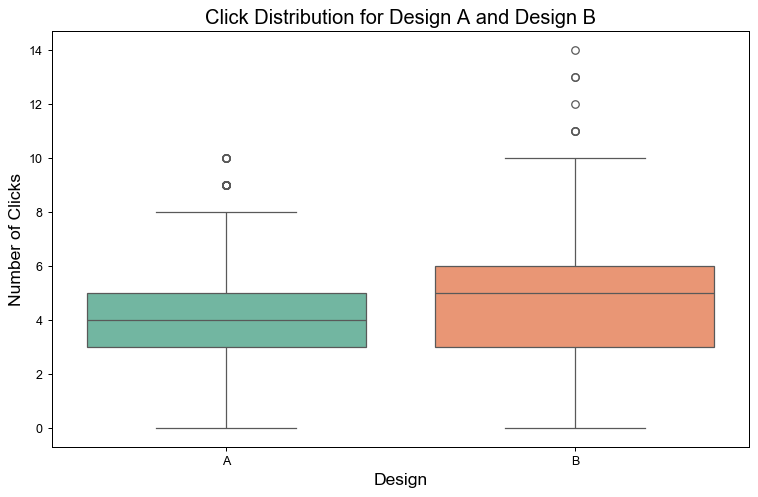

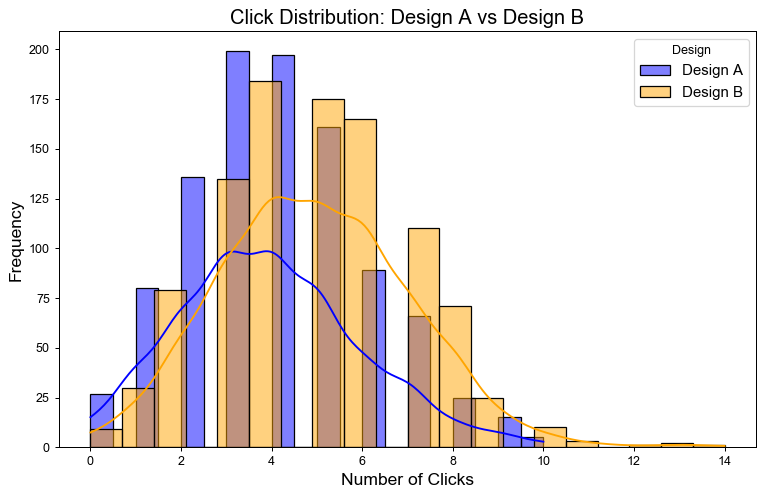

In [3]:
# 绘制点击次数的箱型图
plt.figure(figsize=(10, 6))
sns.boxplot(x='Design', y='Clicks', data=data, palette="Set2")
plt.title('Click Distribution for Design A and Design B', fontsize=16)
plt.xlabel('Design', fontsize=14)
plt.ylabel('Number of Clicks', fontsize=14)
plt.show()

# 绘制点击次数的直方图
plt.figure(figsize=(10, 6))
sns.histplot(group_A, color='blue', kde=True, label='Design A', bins=20)
sns.histplot(group_B, color='orange', kde=True, label='Design B', bins=20)
plt.title('Click Distribution: Design A vs Design B', fontsize=16)
plt.xlabel('Number of Clicks', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Design', fontsize=12)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_008.png)

![原文参考图，当前结果见代码输出](attachments/img_009.png)

1. **箱型图（Boxplot）**：箱型图展示了设计A和设计B的点击次数分布。通过箱型图我们可以直观地看到两个组的中位数、四分位数以及异常值。
2. **直方图（Histogram）**：通过直方图我们可以更清晰地看到设计A和设计B的数据分布情况。结合核密度估计（KDE），可以进一步了解数据的分布形态。

#### 3. 非参数检验：Mann-Whitney U 检验

由于我们无法保证数据服从正态分布，因此使用 **Mann-Whitney U 检验** 来检验两个独立样本（A组和B组）是否来自相同的分布。该检验是一种非参数检验方法，适用于样本量较大且不服从正态分布的情形。

In [4]:
# 进行Mann-Whitney U 检验
stat, p_value = mannwhitneyu(group_A, group_B)

# 输出检验统计量和p值
print(f'Mann-Whitney U statistic: {stat}')
print(f'p-value: {p_value}')

# 判断结果
if p_value < 0.05:
    print("拒绝原假设：两组数据存在显著差异")
else:
    print("无法拒绝原假设：两组数据没有显著差异")

Mann-Whitney U statistic: 361324.0
p-value: 1.966318960698019e-27
拒绝原假设：两组数据存在显著差异


- **U 统计量**：Mann-Whitney U 检验的统计量，用来衡量两组样本之间的差异。
- **p 值**：p 值用于判断原假设（两组数据没有显著差异）是否成立。如果 p 值小于显著性水平（例如 0.05），则拒绝原假设，表示两组数据存在显著差异。

### 4. 结果分析和可视化

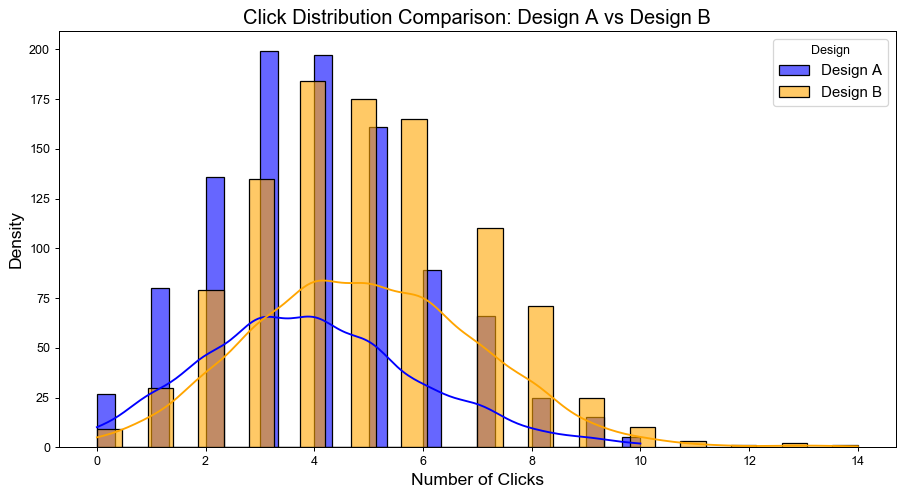

Design A Clicks (mean: 3.92, std: 1.99)
Design B Clicks (mean: 4.94, std: 2.10)


In [5]:
# 将两组数据合并进行可视化
plt.figure(figsize=(12, 6))
sns.histplot(group_A, color='blue', kde=True, label='Design A', bins=30, alpha=0.6)
sns.histplot(group_B, color='orange', kde=True, label='Design B', bins=30, alpha=0.6)
plt.title('Click Distribution Comparison: Design A vs Design B', fontsize=16)
plt.xlabel('Number of Clicks', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Design', fontsize=12)
plt.show()

# 打印详细的检验结果
print(f"Design A Clicks (mean: {np.mean(group_A):.2f}, std: {np.std(group_A):.2f})")
print(f"Design B Clicks (mean: {np.mean(group_B):.2f}, std: {np.std(group_B):.2f})")

![原文参考图，当前结果见代码输出](attachments/img_010.png)

- 通过 **核密度估计（KDE）** 和 **直方图** 比较了设计A和设计B的点击次数分布。
- 输出每组数据的均值和标准差，有助于理解两组数据的中心趋势和离散程度。

#### 5. 算法优化：加速检验过程

在处理大规模数据时，非参数检验（尤其是Mann-Whitney U检验）的计算复杂度较高，可能需要优化。为了提高计算效率，可以通过以下方法进行优化：

- 使用 **分布近似** 或 **Monte Carlo 方法** 来加速U统计量的计算。
- 对于非常大的数据集，可以考虑使用 **并行计算** 来分担检验任务。

In [6]:
from joblib import Parallel, delayed

# 定义计算U统计量的函数
def mann_whitney_parallel(group_A, group_B):
    stat, p_value = mannwhitneyu(group_A, group_B)
    return stat, p_value

# 使用并行计算
results = Parallel(n_jobs=1)(delayed(mann_whitney_parallel)(group_A, group_B) for _ in range(100))  # 并行执行100次

通过Mann-Whitney U检验，我们得出了两种网页设计的点击次数差异的显著性。如果 p 值小于0.05，我们可以拒绝原假设，认为两组数据之间存在显著差异。通过可视化，我们清晰地展示了两组数据的分布差异，同时也通过算法优化提高了处理效率。

整个案例，我们展示了如何在A/B测试中应用非参数检验来分析两组数据之间的差异。我们结合了数据生成、清洗、探索性分析、统计检验、可视化和算法优化的完整流程，希望帮助大家更好地理解如何应用非参数检验。

## 模型分析

### 非参数检验模型的优缺点

**优点：**

1. **不依赖数据分布**：非参数检验方法最大的优点是它不要求数据符合某种特定的分布（例如正态分布）。在实际应用中，很多情况下数据并不符合正态分布，这时候使用非参数检验就显得尤为重要。比如在本案例中，点击次数数据可能是右偏的，并且我们无法假设它们符合正态分布。
2. **适用范围广**：非参数检验能够处理各种类型的数据，尤其适用于小样本数据或者样本量不均的情况。在A/B测试的实际情况中，数据量往往不是非常大，或者可能存在一些极端值，这时非参数检验的表现通常更为稳定。
3. **对异常值不敏感**：非参数检验方法往往基于秩次而非具体数值，这使得它对异常值的敏感度较低。在很多实际应用中，数据可能会包含一些极端值，而这些极端值如果直接影响到检验结果，可能会导致错误的结论。非参数检验通过秩的处理可以减少这种影响。
4. **简单易用**：非参数检验方法相对容易理解和实现，对于非统计专业的人员来说，通常不需要过多关注数据分布的假设，只需要关注秩次的排列和比较。

**缺点**：

1. **效率较低**：相对于一些参数检验方法，非参数检验的计算量较大。例如，Mann-Whitney U检验需要对所有样本进行排序并计算秩次，这在样本量较大时可能导致效率低下，尤其是在处理数百万或更多样本时，计算的时间复杂度会显著增加。
2. **统计功效较低**：非参数检验的统计功效通常低于参数检验。统计功效是指检验能够正确拒绝原假设的概率。如果数据实际上符合某种分布（例如正态分布），使用非参数检验往往无法充分利用数据的分布特性，导致检验结果不如使用参数检验准确。
3. **信息损失**：由于非参数检验主要基于秩次而非原始数据值，因此某些数据的细节可能会丢失。例如，如果数据分布具有特殊的形态（例如均匀分布），非参数检验可能无法揭示这些细节，反而可能错过潜在的信息。
4. **无法提供具体差异的大小**：非参数检验通常只能告诉你两组数据是否存在显著差异，但它并不提供差异的大小或强度。在某些应用场景中，了解差异的具体程度可能比知道差异是否显著更加重要。

### 与相似算法的对比

| **算法** | **优点** | **缺点** | **适用情况** |
|-|-|-|-|
| **Mann-Whitney U检验** | 不依赖数据分布，适用于非正态分布，计算较简单；对异常值不敏感 | 计算效率低，尤其在样本量较大时，统计功效低，信息损失较大 | 样本量适中，数据不满足正态分布时，或需要避免异常值的影响时 |
| **t检验（独立样本）** | 计算效率高，适用于正态分布数据，能够提供差异的大小（效应量） | 假设数据符合正态分布，不适用于小样本或非正态分布数据 | 数据服从正态分布且样本量较大时 |
| **方差分析（ANOVA）** | 可比较三个及以上组，能有效比较均值差异，适用于正态分布数据 | 假设数据服从正态分布，且组内方差齐性，数据不符合时可能导致误差 | 比较三个及以上组的数据，且数据符合正态分布时 |
| **Kruskal-Wallis检验** | 比较多个组的差异，不依赖数据分布，适合小样本或非正态分布数据 | 计算效率低，无法提供差异的具体大小（仅知差异是否显著） | 比较多个独立样本组的数据且数据非正态时 |
| **Bootstrap（自助法）** | 不依赖分布假设，能通过重复抽样估计统计量分布，灵活性强 | 计算量大，尤其在样本量较大时，结果可能不稳定 | 样本量较小，或对分布假设没有信心时 |
| **Permutation测试** | 无分布假设，适用范围广，精确检验，灵活性强 | 计算量大，尤其是样本量较大时，效率低 | 样本量较小，或无法假设数据分布时 |

### 何时优选非参数检验，何时可以考虑其他算法？

**何时优选非参数检验（如Mann-Whitney U检验）**：

1. **数据不符合正态分布**：如果数据明显不符合正态分布（例如存在明显的偏态或峰度），非参数检验通常是更好的选择。使用参数检验如t检验时，假设数据符合正态分布，但非正态分布的数据可能导致错误的结论。
2. **样本量较小**：在小样本的情况下，正态性假设往往难以成立，使用非参数检验可以避免因样本量过小而引起的检验偏差。非参数检验通常在样本量较小或数据分布未知时更为稳健。
3. **存在异常值**：当数据中存在极端值时，非参数检验（特别是基于秩次的检验）对异常值不太敏感，可以有效避免这些异常值对检验结果的影响。
4. **不关心差异的大小**：非参数检验主要关注的是是否存在显著的差异，而不是差异的具体大小。如果你的研究目标是判断两组数据是否存在差异，而不是比较差异的强度，非参数检验是一个很好的选择。

**何时考虑使用其他算法**：

1. **数据符合正态分布**：如果数据显著符合正态分布，可以考虑使用参数检验方法，如独立样本t检验或方差分析（ANOVA）。这些方法通常比非参数检验更具统计功效，即能够更好地识别实际差异。
2. **较大的样本量**：在样本量较大的情况下，t检验等参数检验的统计功效较高，且计算效率更高。如果数据已经验证为符合正态分布，使用这些参数方法通常可以更高效地得出结论。
3. **需要评估效应大小**：如果研究不仅关心是否有显著差异，还需要评估差异的大小，参数检验（如t检验）可以提供效应量（例如Cohen's d），这对于评估差异的实际意义更为重要。

### 最后

非参数检验方法在很多情况下是非常有用的，尤其是当数据不符合正态分布、存在异常值，或样本量较小的情况下。然而，在数据符合正态分布且样本量足够大的情况下，使用传统的参数检验方法（如t检验和ANOVA）通常更加高效和精确。因此，选择何种检验方法应该根据数据的具体分布特性、样本量大小以及研究目标来决定。